In [1]:
# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib
import matplotlib.pyplot as plt

In [2]:
# Ячейка № 2

# задание функции,
# возвращающей значения
# базисной функции,
# используемой для конструирования
# точного решения ДУ (8.151) с S = 0
def FNGAUSS(t, x):
    z = np.exp(-20 * (x - 0.5) ** 2 / (1 + 80 * t)) / np.sqrt(1 + 80 * t)

    return z

In [3]:
# Ячейка № 3

# задание функции, возвращающей
# значения точного решения (8.152) c S = 0
def FNEXACT(t, x):
    z = FNGAUSS(t, x) - FNGAUSS(t, x - 1) - FNGAUSS(t, x + 1)

    return z


In [ ]:
# Ячейка № 4

# задание функции, возвращающей
# координаты узлов сетки по оси OX,
# координаты узлов ВС,
# аналитическое решение СДУ (8.151),
# численное решение СДУ (8.151),
# мгновенных значений
# среднеквадратических отклонений
# разностей между численным и аналитическим
# решениями СДУ (8.151)
def max_Delta(Nx, Nt, dt):
    # входные переменные
    # Nx - число узлов координатной сетки
    # Nt - число узлов ВС
    # dt - шаг ВС

    # вычисление значений координат
    # узлов координатной сетки
    x = np.linspace(0, 1.0, Nx)

    # вычисление шага координатной сетки
    dx = x[1] - x[0]

    t = np.arange(0, Nt * dt, dt)

    NT = len(t)

    # вычисление отношения шага временной сетки к
    # квадрату шага координатной сетки
    dTH = dt / dx**2

    # инициализация массива,
    # используемого для вычисления
    # конечно-разностной производной по времени
    Phi = np.zeros(Nx)

    # инициализация массива, используемого для
    # хранения численных решений ДУ (8.151)
    S_d = np.zeros([NT, Nx])

    # инициализация массива, используемого для
    # хранения точных решений ДУ (8.152)
    S_a = np.zeros([NT, Nx])

    # задание начальных условий
    for i in range(Nx - 2):
        Phi[i + 1] = FNEXACT(0, x[i + 1])

    # Задание граничных условий
    for i in range(Nx - 1):
        S_a[0, i + 1] = Phi[i + 1]
        S_d[0, i + 1] = Phi[i + 1]

    # вычисление значений точного решения ДУ(8.151)
    # в узлах используемой координатно-временной сетки
    for i in range(NT - 1):
        for m in range(Nx - 2):
            S_a[i + 1, m + 1] = FNEXACT(t[i + 1], x[m + 1])

    # вычисление численного решения ДУ (8.151)
    for i in range(NT - 1):
        Pt = 0
        for m in range(Nx - 2):
            Ps = Phi[m + 1] + dTH * (Pt + Phi[m + 2] - 2 * Phi[m + 1])
            Pt = Phi[m + 1]
            Phi[m + 1] = Ps
        S_d[i + 1, :] = Phi[:]

    # вычисление мгновенных разностей
    # между численным и аналитическим
    # решениями СДУ (8.151)
    S = S_d - S_a

    # инициализация массива S_v
    S_v = np.zeros(NT)

    # вычисление мгновенных значений
    # среднеквадратических отклонений
    # разностей между численным и аналитическим
    # решениями СДУ (8.151)
    for i in range(NT):
        S_v[i] = np.var(S[i, :])

    return t, x, S_a, S_d, S, S_v


dt/dx^2 =  0.4802000000000001


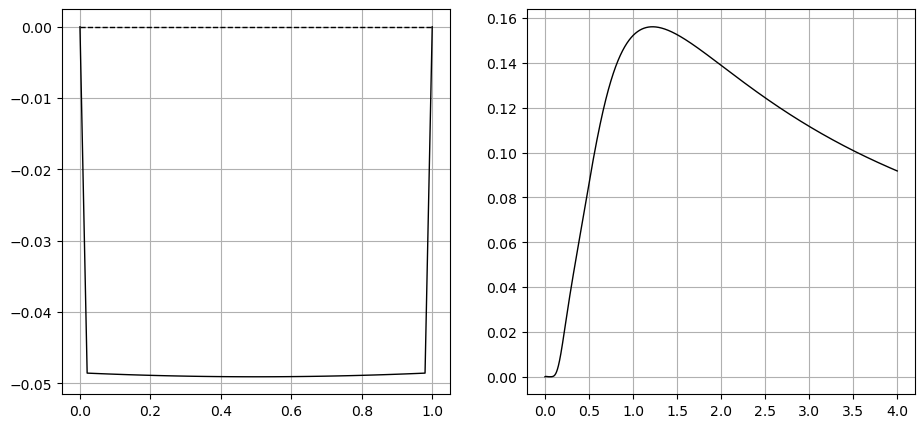

In [5]:
# Ячейка № 5

# задание числа узлов координатной сетки
Nx = 50

# задание числа узлов ВС
Nt = 20000

# задание шага ВС
dt = 2 * 10**-4

# печать значения коэффициента dt/dx^2
print("dt/dx^2 = ", dt / (1 / (Nx - 1)) ** 2)

# вычисление координат узлов ВС (t),
# значений аналитического решение СДУ (8.151) (S_a),
# численного решения СДУ (8.151) (S_d),
# мгновенных значений
# среднеквадратических отклонений
# разностей между численным и аналитическим
# решениями СДУ (8.151) (S_var)
t, x, S_a, S_d, S, S_var = max_Delta(Nx, Nt, dt)


fig = plt.figure(figsize=(11, 5))

# визуализация аналитического
# и численного решений СДУ (8.151)
ax = fig.add_subplot(1, 2, 1)
ax.plot(x, S_a[Nt - 1, :], "-k", lw=1)
ax.plot(x, S_d[Nt - 1, :], "--k", lw=1)
ax.grid(True)

# визуализация зависимости
# среднеквадратических отклонений
# разностей между численным и аналитическим
# решениями СДУ (8.151) от времени
ax1 = fig.add_subplot(1, 2, 2)
ax1.plot(t, S_var * 10**3, "-k", lw=1)
ax1.grid(True)

plt.show()